In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import shap
from sklearn.inspection import PartialDependenceDisplay

In [2]:
sns.set_theme(style="whitegrid", palette="muted")


In [3]:
file_path = '/content/TEAM22_Master_Dataset.csv'
df = pd.read_csv(file_path)

display(df.head())

,Patient_ID,MCHC,Anti_tissue_transglutaminase,MCV,Progesterone_antibodies,Eosinophils,Anti_desmoglein_1,Weight loss,Anti_parietal_cell,C3,...,Dizziness,ACPA,Anti_BP230,Brittle hair or hair loss,C1_inhibitor,Anti_CBir1,DGP,EMA,anti_Scl_70,Gender
0,1,33.12,0.0,99.85,0.0,4.02,0.0,0.0,0.0,1.32,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female
1,2,31.07,0.0,94.86,0.0,1.67,0.0,1.0,0.0,0.40,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Male
2,3,35.61,0.0,88.26,0.0,4.32,0.0,0.0,0.0,0.95,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Male
3,4,33.93,0.0,85.95,0.0,3.12,0.0,1.0,0.0,1.06,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Female
4,5,31.29,0.0,93.16,0.0,4.60,0.0,1.0,0.0,0.73,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female


# Data Quality & Health Check

In [4]:
df.head()


,Patient_ID,MCHC,Anti_tissue_transglutaminase,MCV,Progesterone_antibodies,Eosinophils,Anti_desmoglein_1,Weight loss,Anti_parietal_cell,C3,...,Dizziness,ACPA,Anti_BP230,Brittle hair or hair loss,C1_inhibitor,Anti_CBir1,DGP,EMA,anti_Scl_70,Gender
0,1,33.12,0.0,99.85,0.0,4.02,0.0,0.0,0.0,1.32,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female
1,2,31.07,0.0,94.86,0.0,1.67,0.0,1.0,0.0,0.40,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Male
2,3,35.61,0.0,88.26,0.0,4.32,0.0,0.0,0.0,0.95,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Male
3,4,33.93,0.0,85.95,0.0,3.12,0.0,1.0,0.0,1.06,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Female
4,5,31.29,0.0,93.16,0.0,4.60,0.0,1.0,0.0,0.73,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45205 entries, 0 to 45204
Data columns (total 79 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Patient_ID                            45205 non-null  int64  
 1   MCHC                                  45205 non-null  float64
 2   Anti_tissue_transglutaminase          45205 non-null  float64
 3   MCV                                   45205 non-null  float64
 4   Progesterone_antibodies               45205 non-null  float64
 5   Eosinophils                           45205 non-null  float64
 6   Anti_desmoglein_1                     45205 non-null  float64
 7   Weight loss                           45205 non-null  float64
 8   Anti_parietal_cell                    45205 non-null  float64
 9   C3                                    45205 non-null  float64
 10  Hematocrit                            45205 non-null  float64
 11  pANCA          

In [6]:
df.isnull().sum()


,0
Patient_ID,0
MCHC,0
Anti_tissue_transglutaminase,0
MCV,0
Progesterone_antibodies,0
...,...
Anti_CBir1,0
DGP,0
EMA,0
anti_Scl_70,0


In [7]:
df.drop_duplicates(inplace=True)


# Target Variable Analysis (Class Imbalance)

shows many patients we have for each disease


In [8]:
target_col = 'Diagnosis'
print("DISEASE DISTRIBUTION")
display(df[target_col].value_counts())

DISEASE DISTRIBUTION


,count
Diagnosis,
Normal,6960
Autoimmune orchitis,5142
Systemic lupus erythematosus (SLE),5016
Endometriosis,5000
Rheumatoid arthritis,4711
...,...
Sydenham's chorea,68
Rheumatic heart disease,67
Polyarteritis nodosa (PAN),63


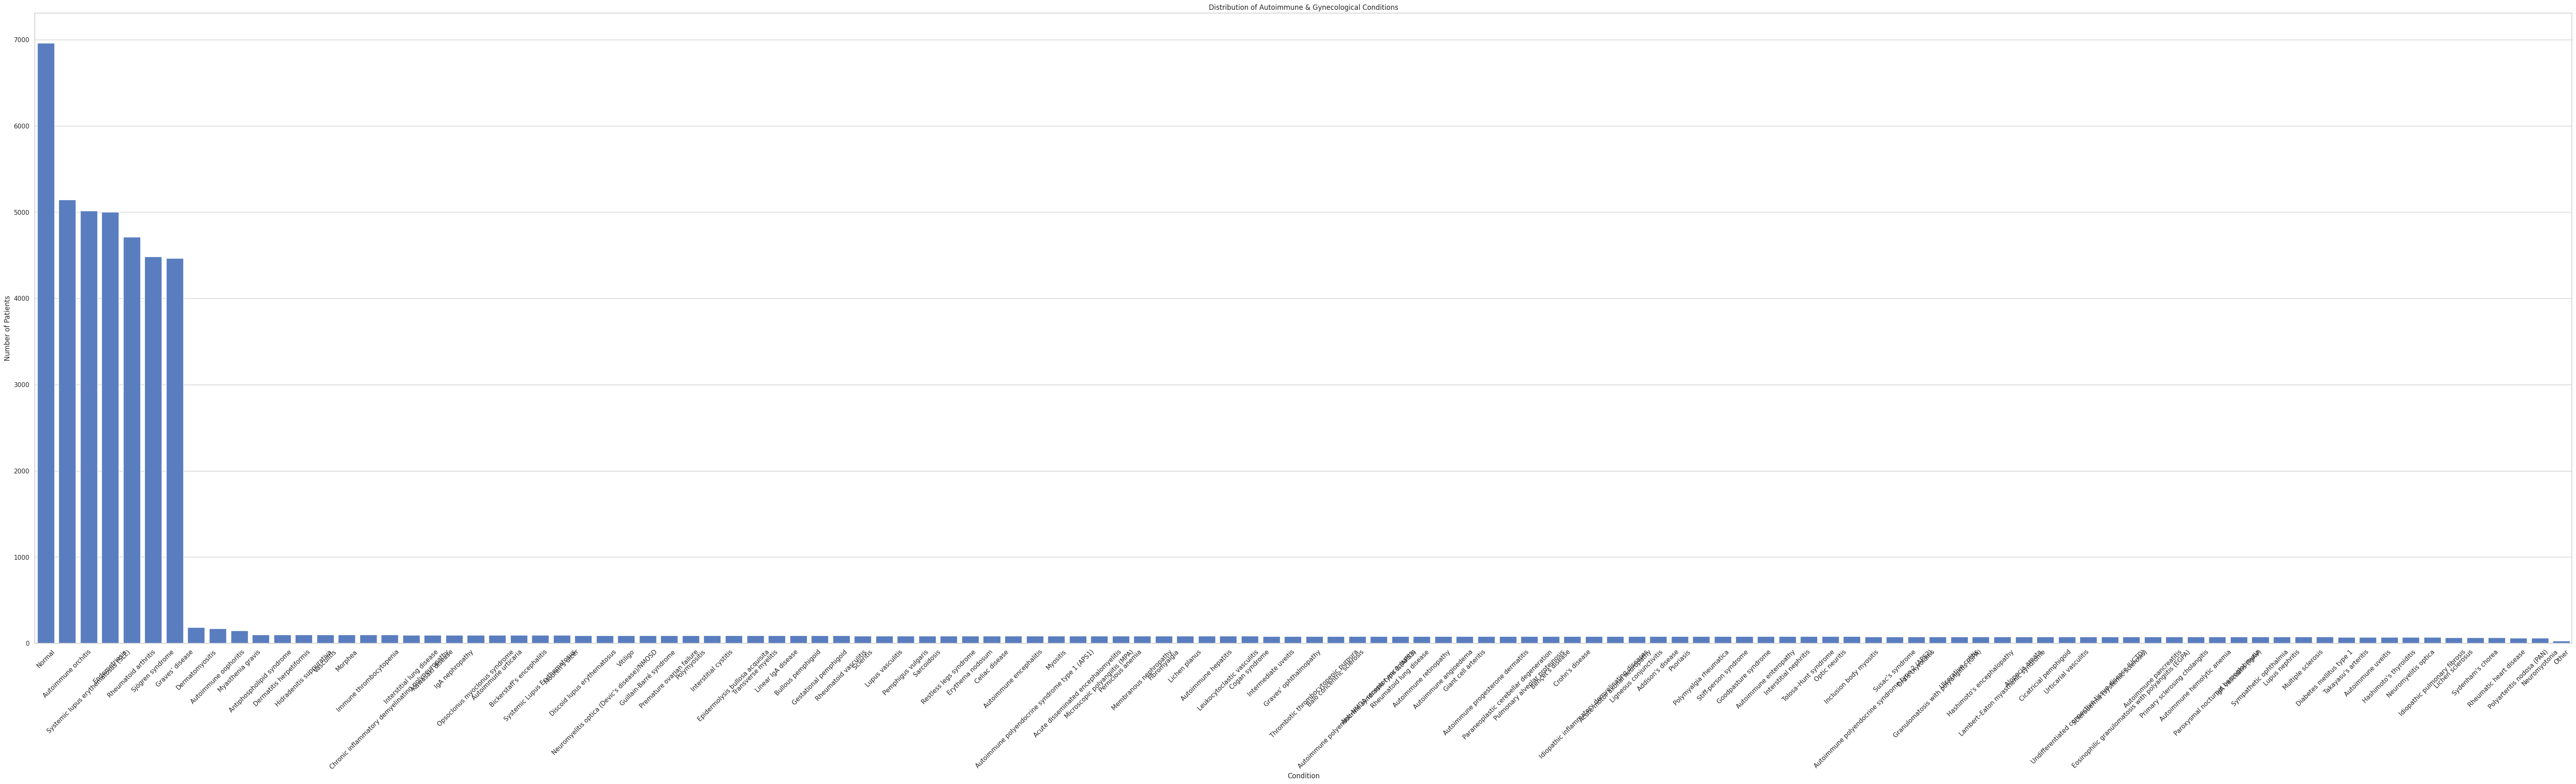

In [9]:
plt.figure(figsize=(80, 20))
sns.countplot(data=df, x=target_col, order=df[target_col].value_counts().index)
plt.title('Distribution of Autoimmune & Gynecological Conditions')
plt.xlabel('Condition')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()

# Univariate Analysis (Examining Clinical Features)

histograms for first 6 numerical features to check for outliers


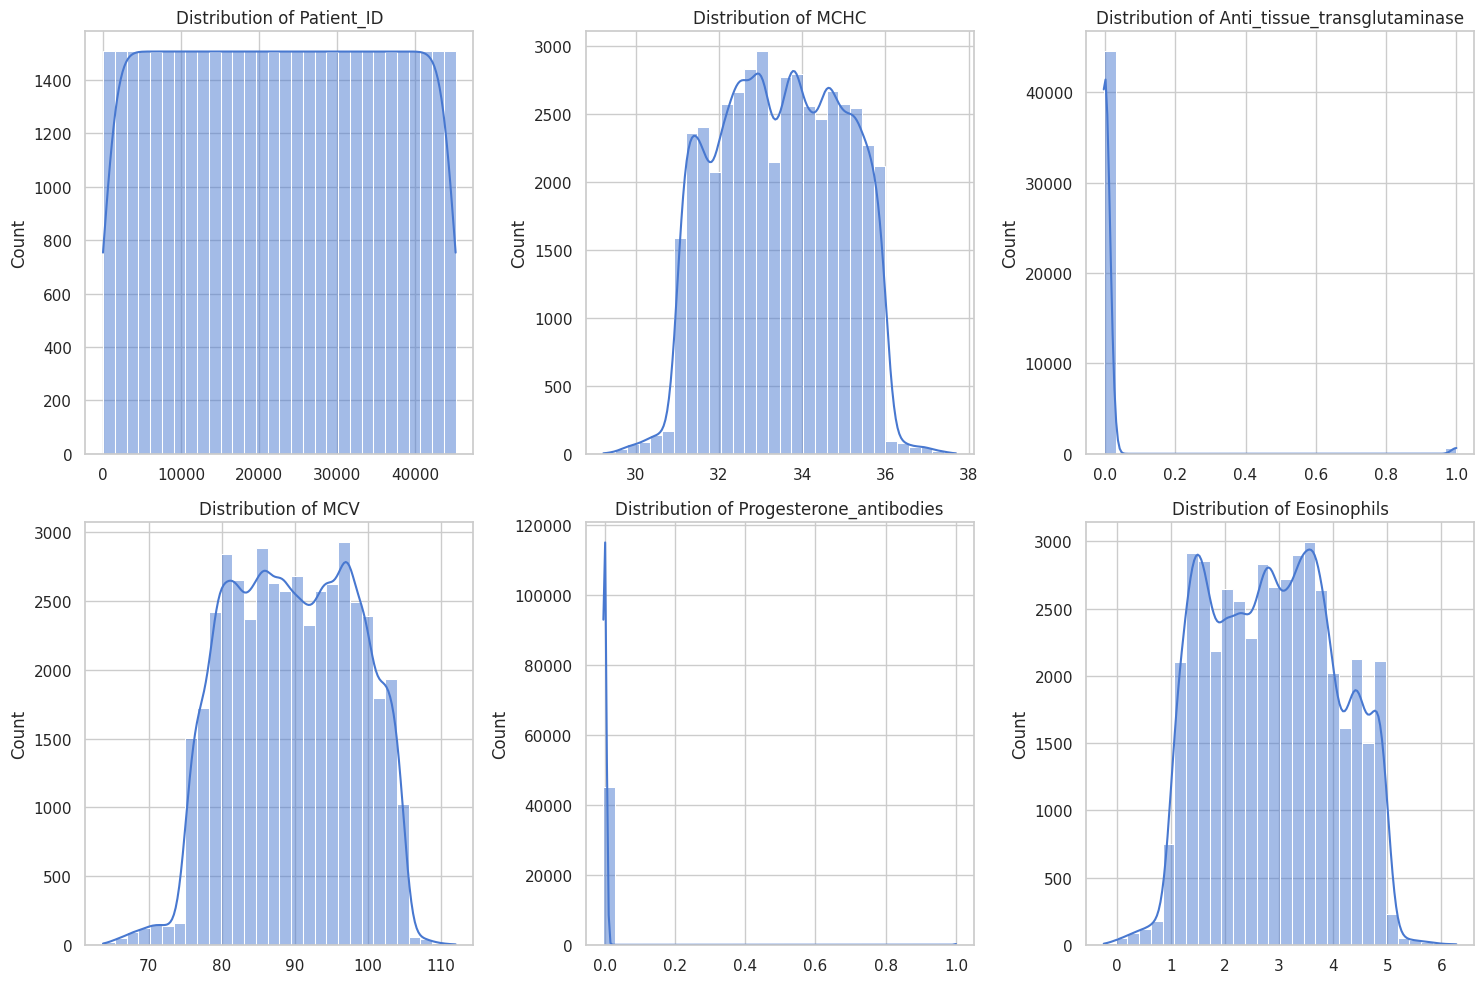

In [10]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols[:6], 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

Quick histograms for all numerical columns at once

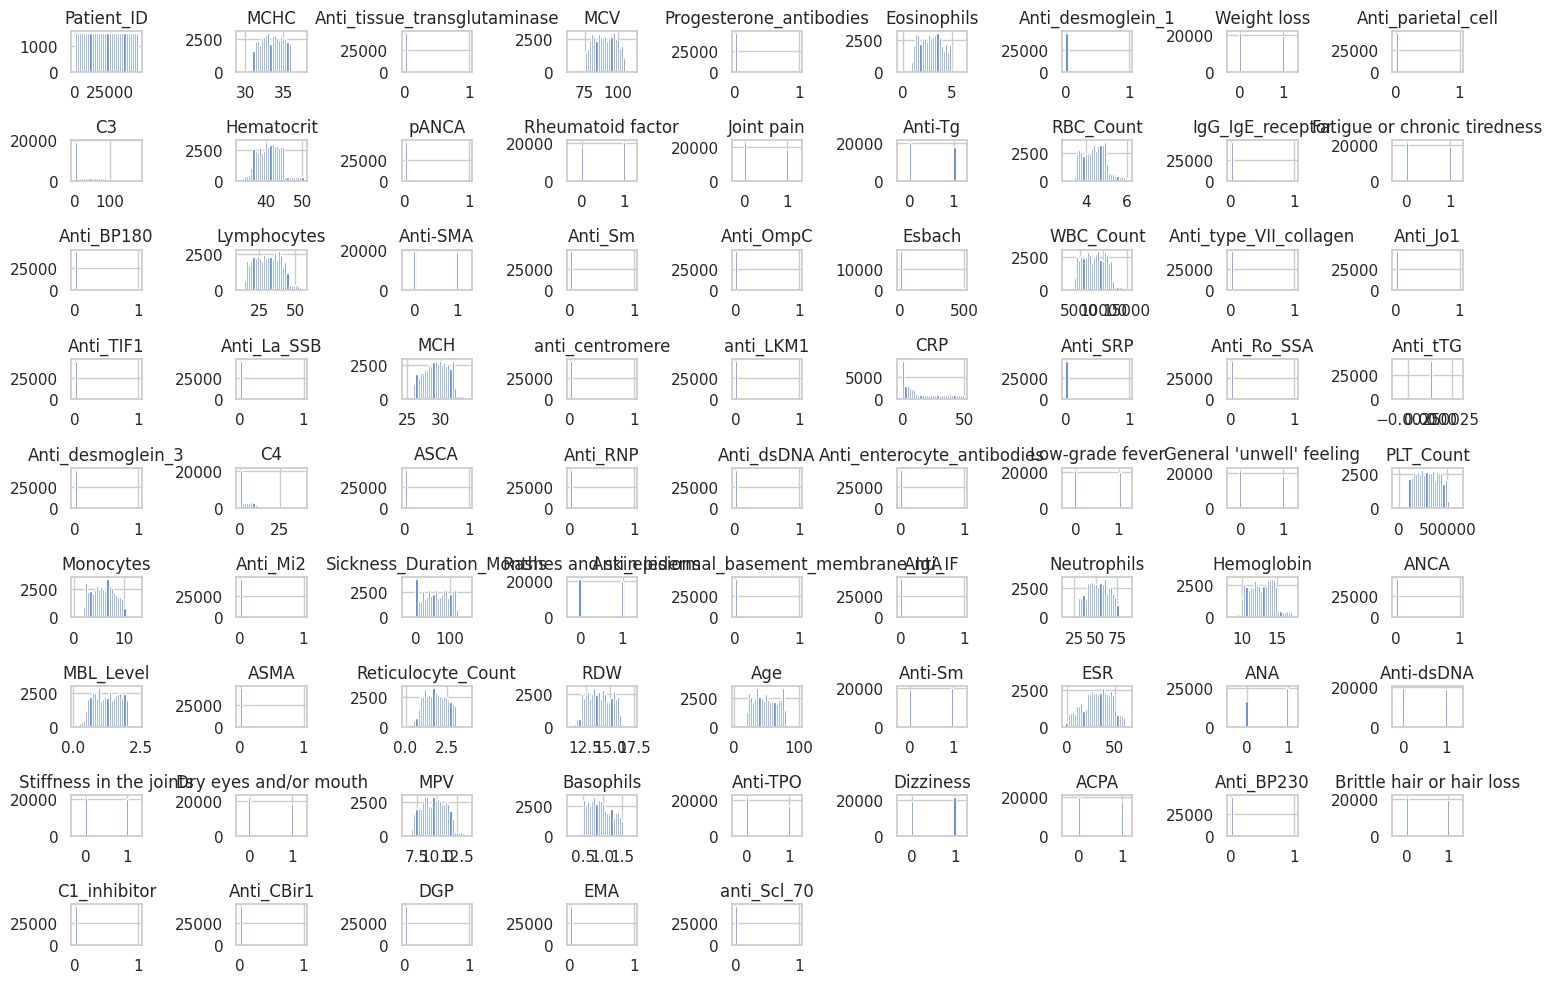

In [11]:
df[num_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()



# Bivariate Analysis (Features vs. Diseases)

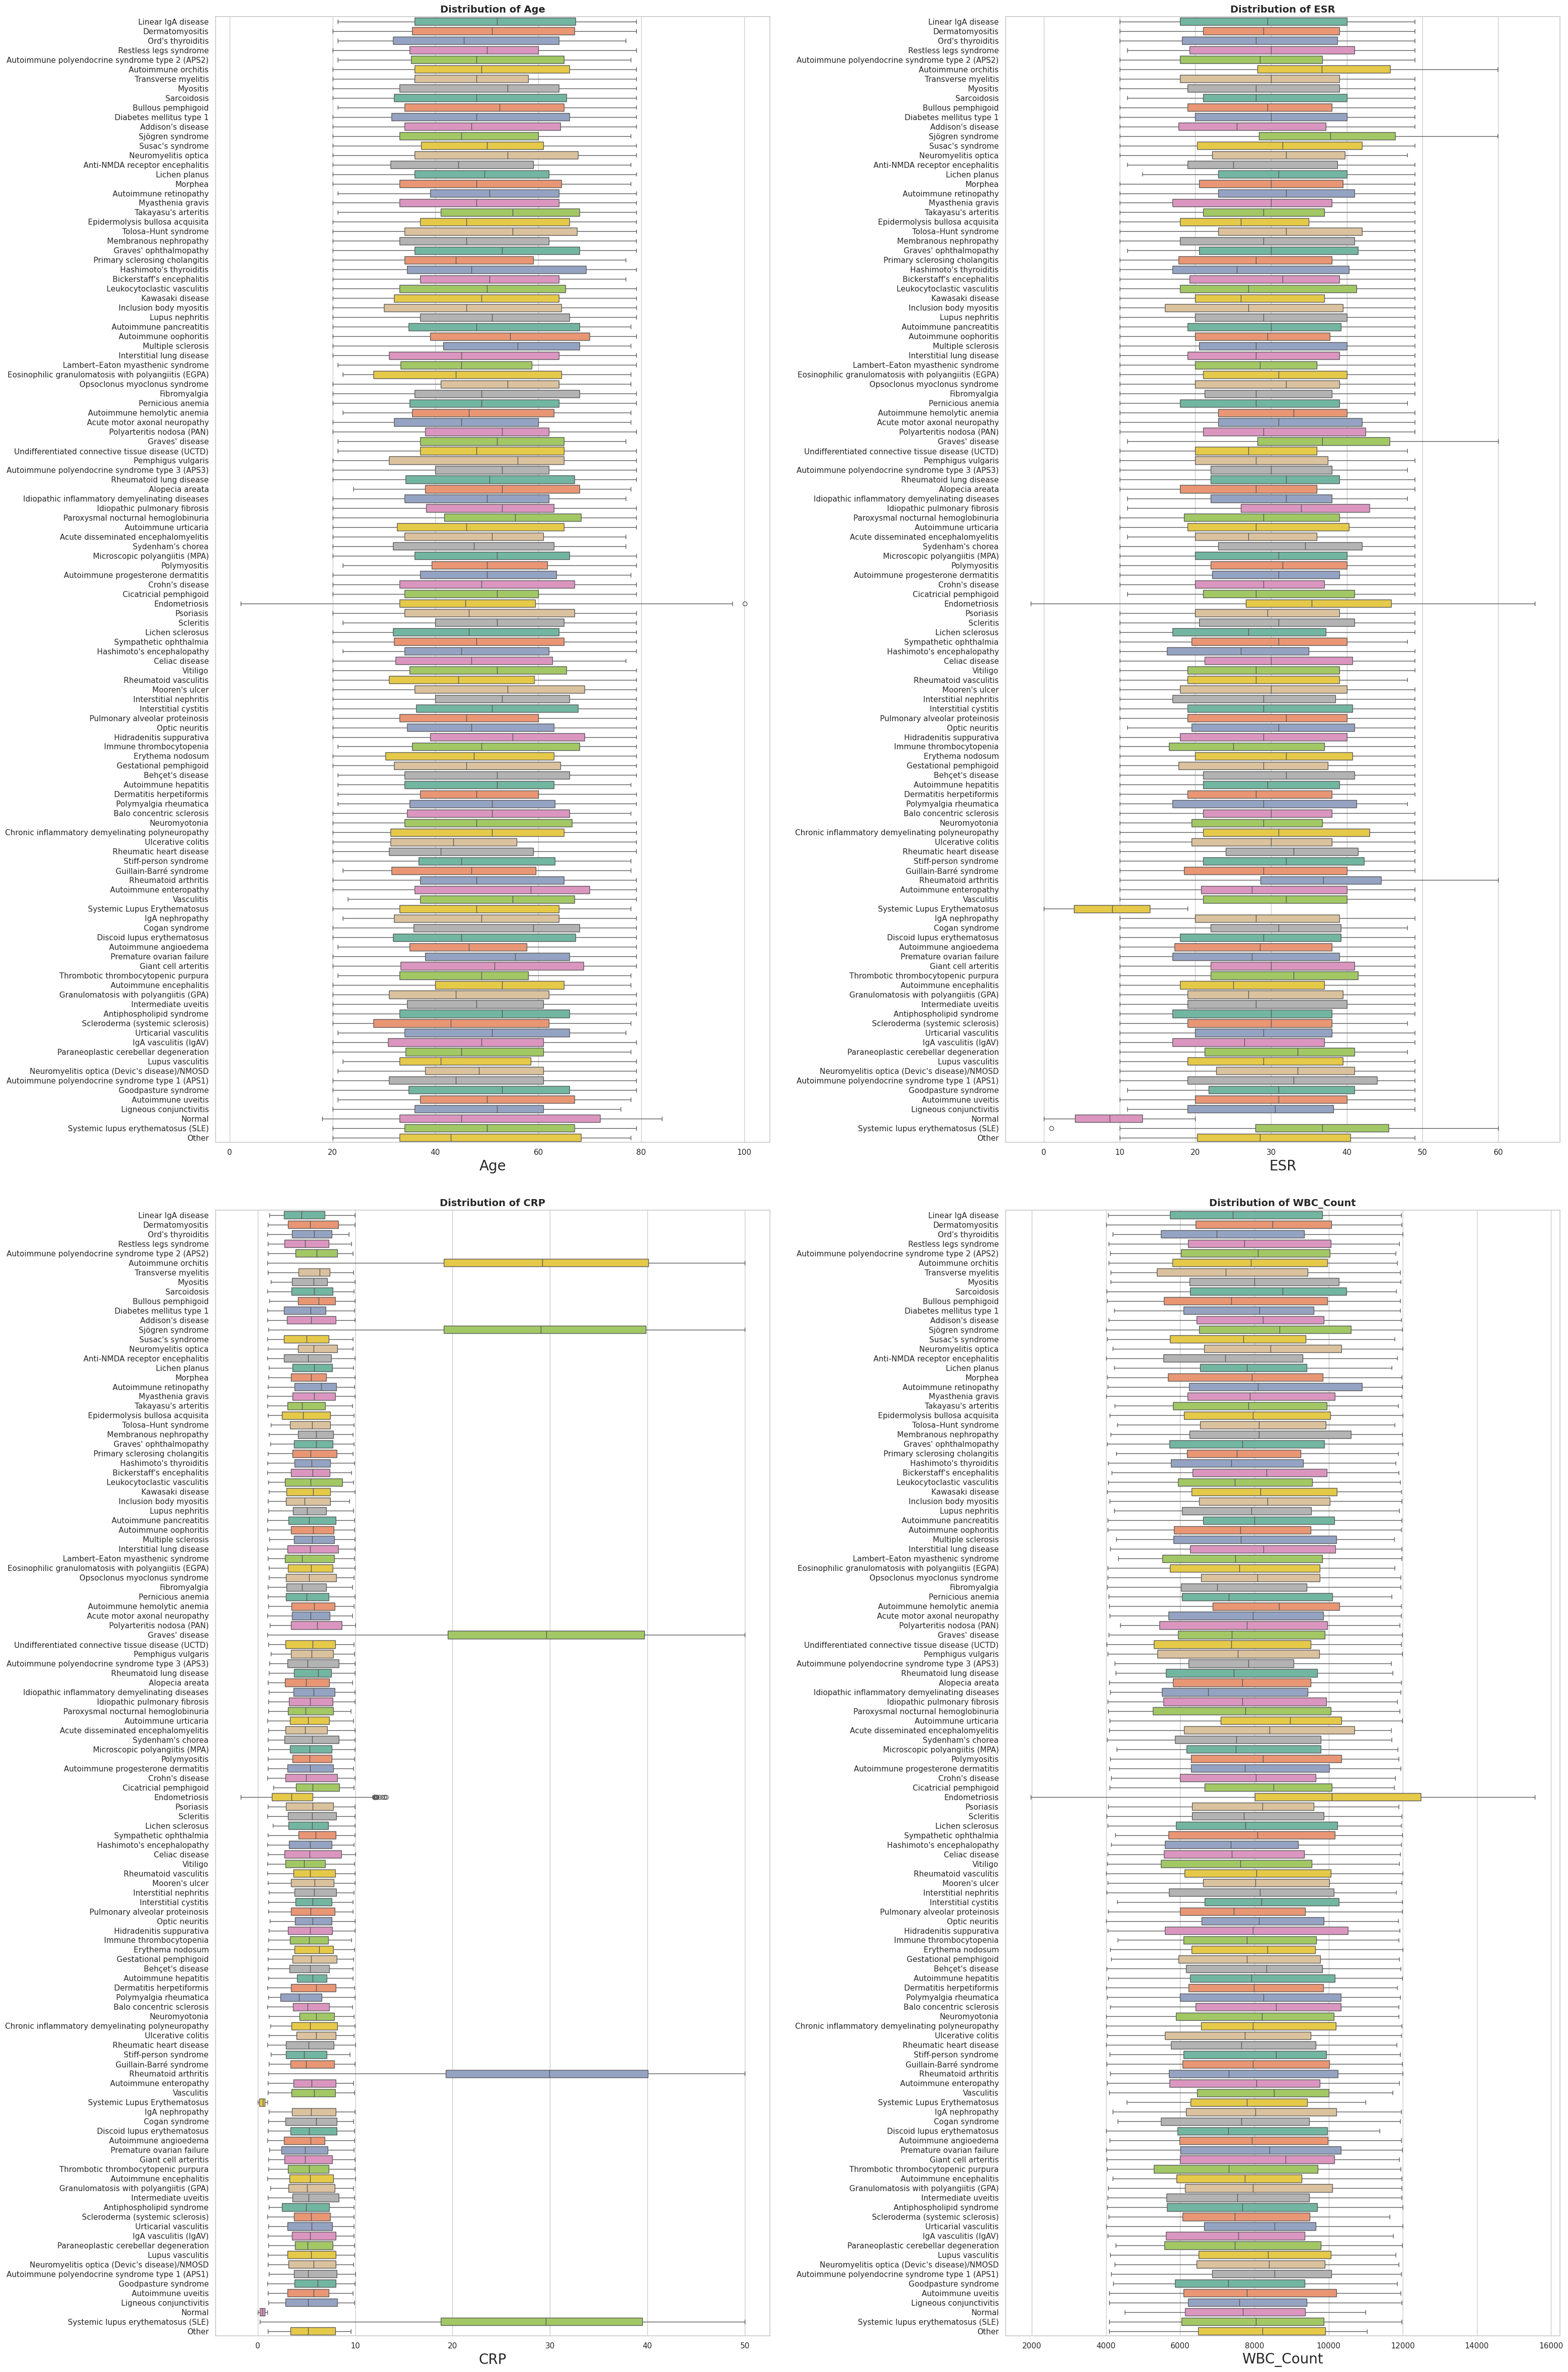

In [12]:
features_to_compare = ['Age', 'ESR', 'CRP', 'WBC_Count']
plt.figure(figsize=(32, 48))
for i, col in enumerate(features_to_compare, 1):
    plt.subplot(2, 2, i)

    sns.boxplot(data=df, y=target_col, x=col, hue=target_col, palette="Set2", legend=False)

    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.ylabel('')
    plt.xlabel(col, fontsize=20)

plt.tight_layout(pad=3.0)
plt.show()

Bivariate Analysis (Features vs. TOP 5 Diseases)


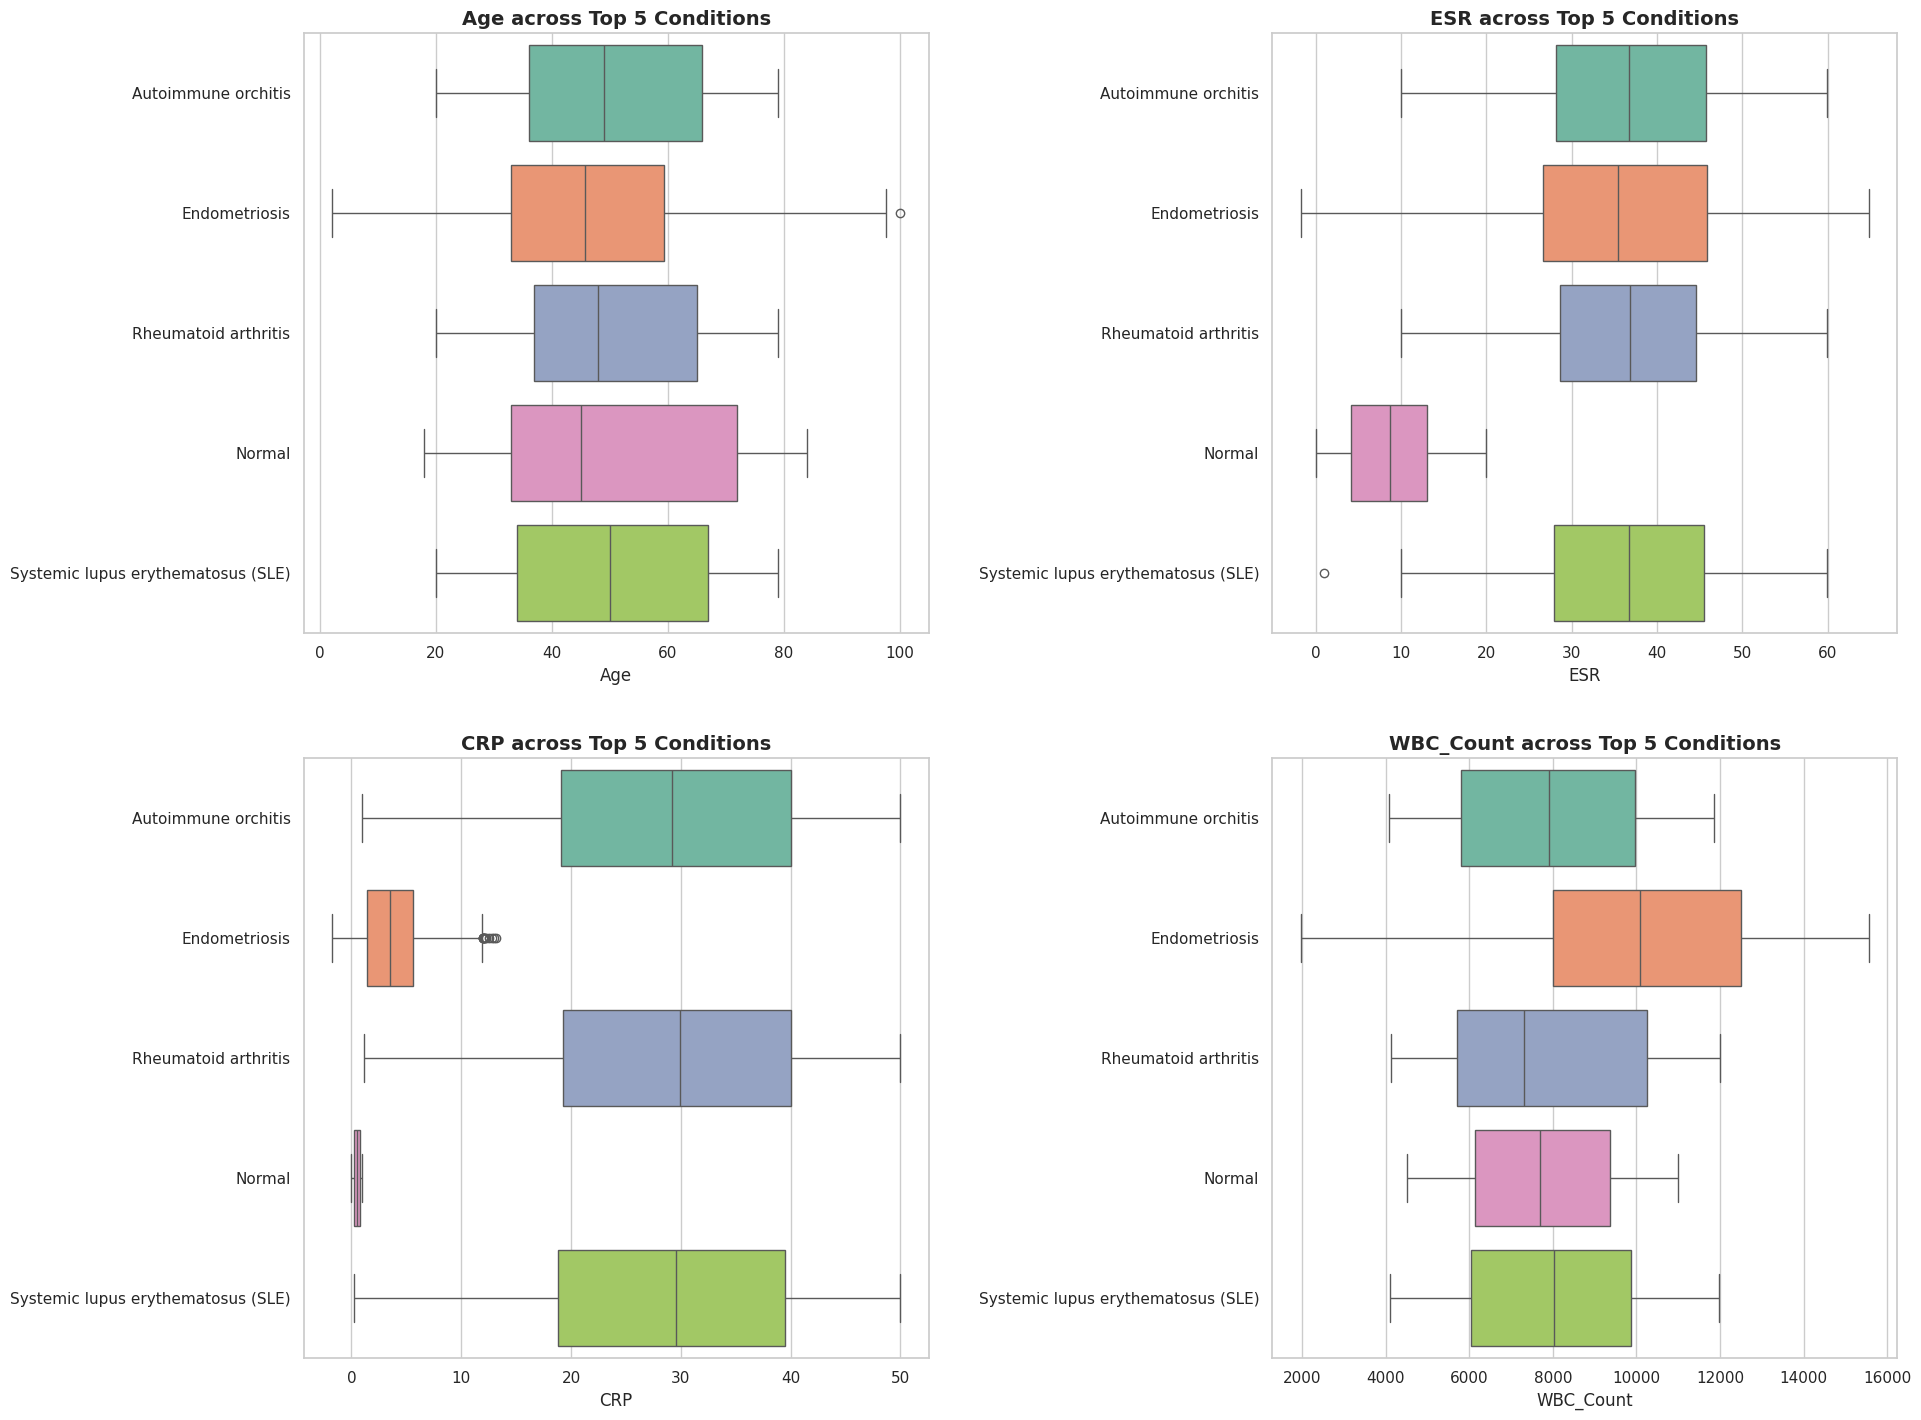

In [13]:
target_col = 'Diagnosis'
features_to_compare = ['Age', 'ESR', 'CRP', 'WBC_Count']

top_5_diseases = df[target_col].value_counts().index[:5]
df_top5 = df[df[target_col].isin(top_5_diseases)]

plt.figure(figsize=(20, 15))
for i, col in enumerate(features_to_compare, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df_top5, y=target_col, x=col, hue=target_col, palette="Set2", legend=False)
    plt.title(f'{col} across Top 5 Conditions', fontsize=14, fontweight='bold')
    plt.ylabel('')
    plt.xlabel(col, fontsize=12)

plt.tight_layout(pad=3.0)
plt.show()

# Multivariate Analysis (Correlation & Multicollinearity)

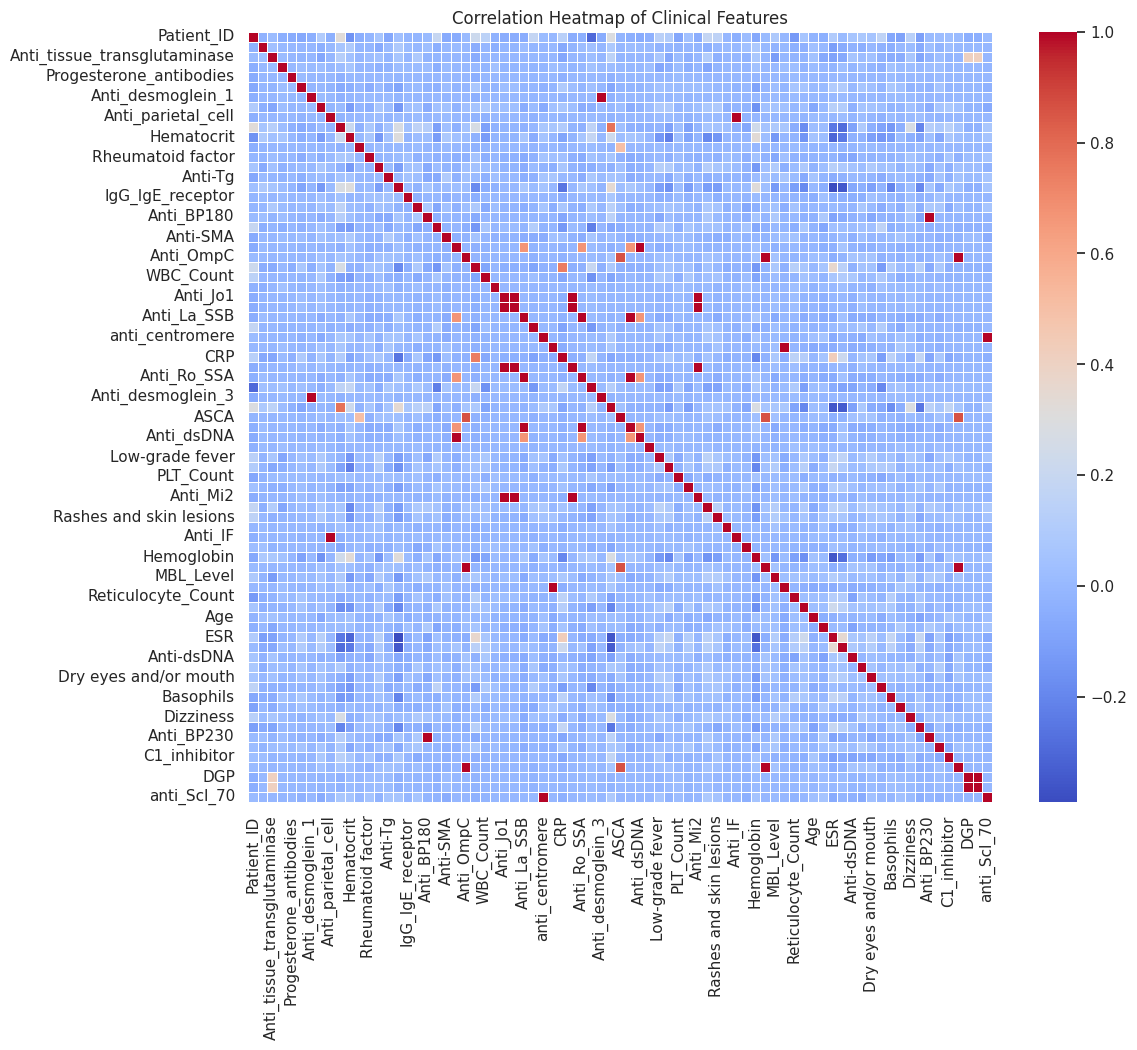

HIGHLY CORRELATED FEATURES (> 0.8)
Consider dropping these columns: ['Anti_TIF1', 'Anti_SRP', 'Anti_Ro_SSA', 'Anti_desmoglein_3', 'ASCA', 'Anti_RNP', 'Anti_dsDNA', 'Anti_Mi2', 'Anti_IF', 'ANCA', 'ASMA', 'Anti_BP230', 'Anti_CBir1', 'EMA', 'anti_Scl_70']


In [14]:
plt.figure(figsize=(12, 10))

# بCalculate the correlation matrix for numerical features
corr_matrix = df[num_cols].corr()

#elheatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Clinical Features')
plt.show()

print("HIGHLY CORRELATED FEATURES (> 0.8)")
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.8)]
print(f"Consider dropping these columns: {high_corr}")

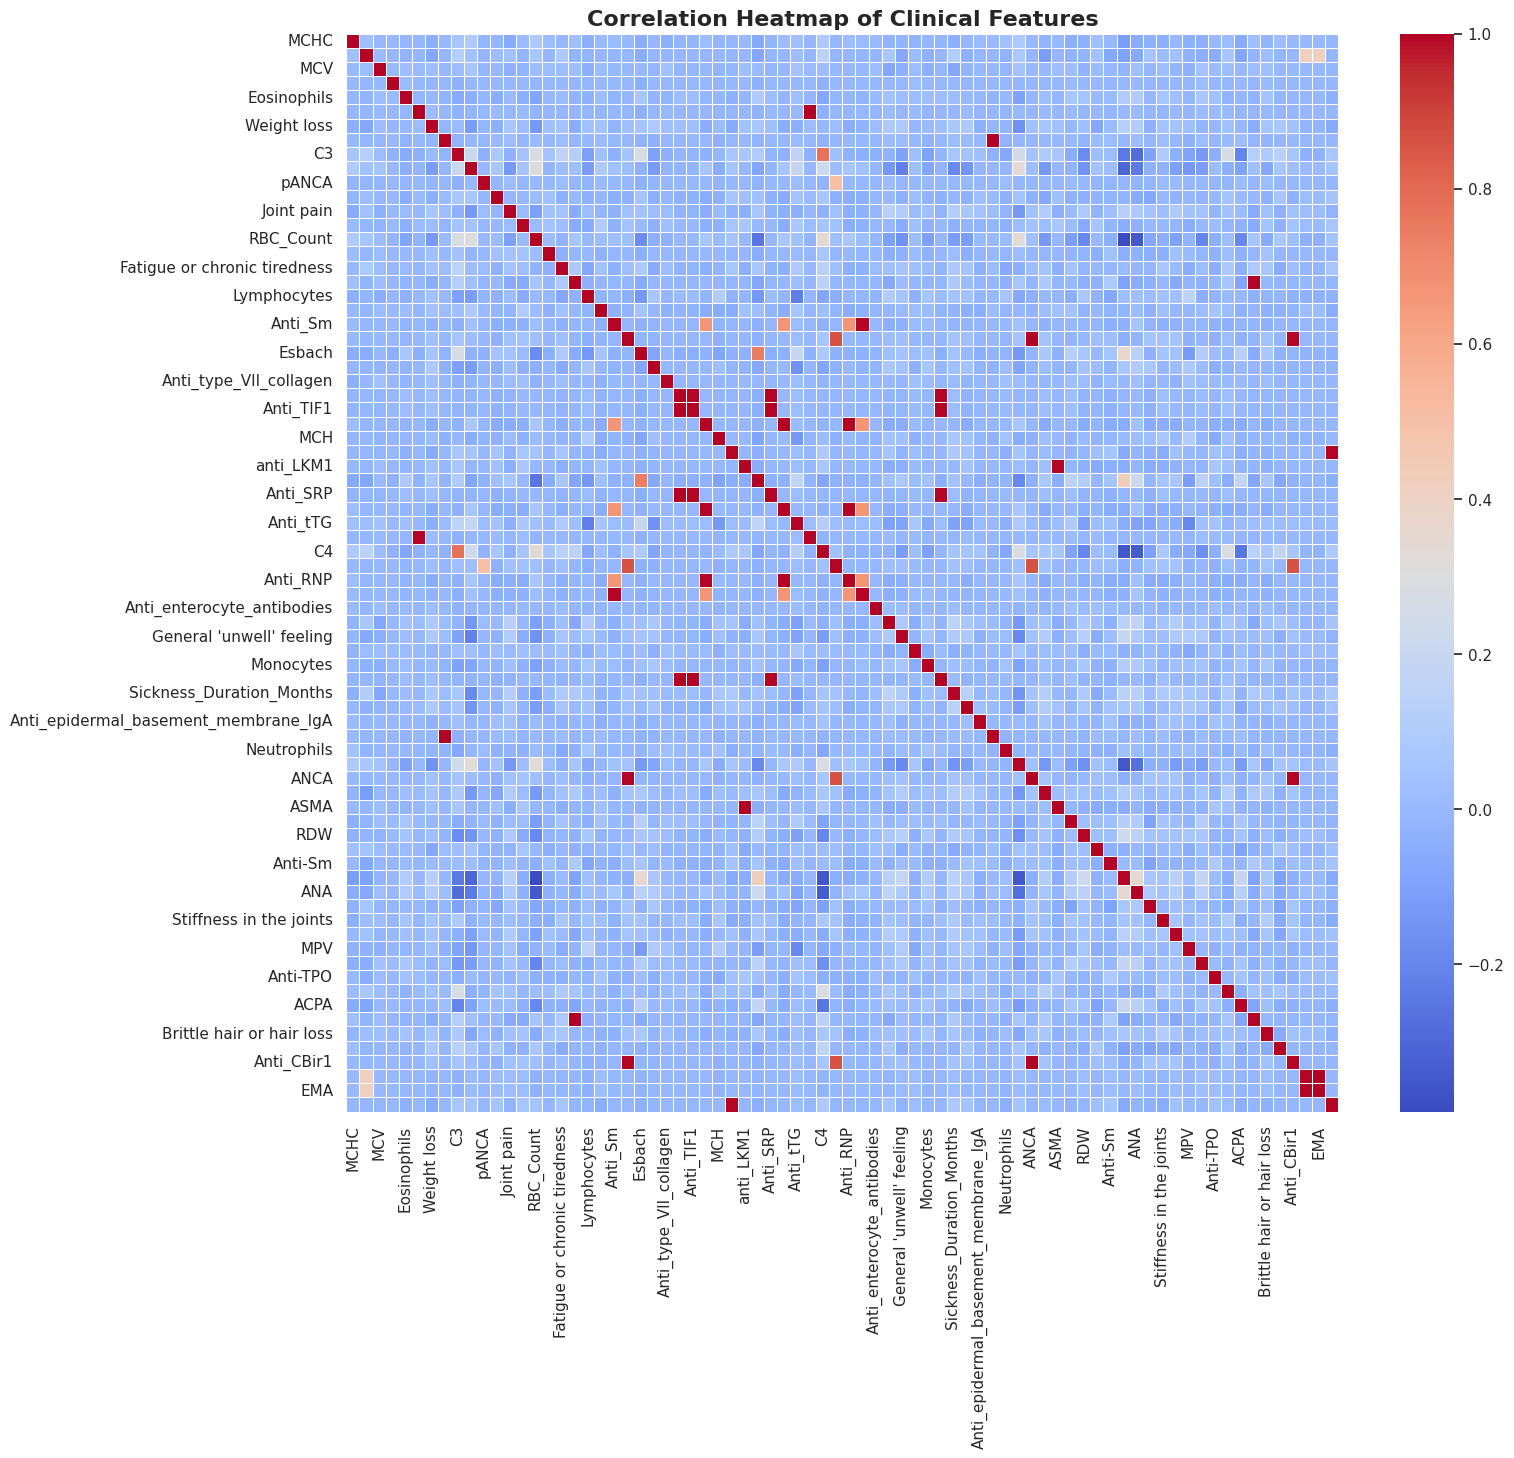

In [15]:
# numerical columns and remove'Patient_ID' as it has no clinical value
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = num_cols.drop('Patient_ID', errors='ignore')

plt.figure(figsize=(16, 14))
corr_matrix = df[num_cols].corr()

#the_heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Clinical Features', fontsize=16, fontweight='bold')
plt.show()


In [16]:
#highly correlated features (threshold > 0.8)
print("HIGHLY CORRELATED FEATURES (> 0.8)")
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.8)]
print(f"Consider dropping these columns: {high_corr}")

HIGHLY CORRELATED FEATURES (> 0.8)
Consider dropping these columns: ['Anti_TIF1', 'Anti_SRP', 'Anti_Ro_SSA', 'Anti_desmoglein_3', 'ASCA', 'Anti_RNP', 'Anti_dsDNA', 'Anti_Mi2', 'Anti_IF', 'ANCA', 'ASMA', 'Anti_BP230', 'Anti_CBir1', 'EMA', 'anti_Scl_70']


# Categorical Analysis (Gender)


/tmp/ipykernel_16315/3936932106.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='pastel')


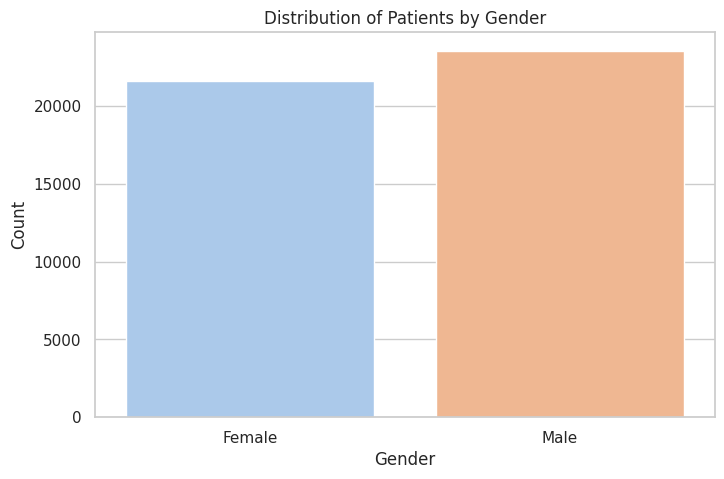

In [17]:
if 'Gender' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x='Gender', palette='pastel')
    plt.title('Distribution of Patients by Gender')
    plt.xlabel('Gender')
    plt.ylabel('Count')
    plt.show()

Raneem's work

In [18]:
!pip install xgboost shap fairlearn

#Feature Selection (0.5 pts):

In [19]:
from sklearn.impute import SimpleImputer
from fairlearn.metrics import MetricFrame, false_negative_rate

In [20]:
df_model = df.copy()
df_model['Target'] = df_model['Diagnosis'].apply(lambda x: 1 if x == 'Systemic lupus erythematosus (SLE)' else 0)

In [21]:
cols_to_drop = ['Patient_ID', 'Diagnosis']
if 'high_corr' in locals():
    cols_to_drop += high_corr


In [22]:
df_model = df_model.drop(columns=cols_to_drop, errors='ignore')

text columns to numbers

In [23]:
le = LabelEncoder()
for col in df_model.select_dtypes(include=['object']).columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

Encode Gender Male/Female to 0/1

In [24]:
le_gender = LabelEncoder()
df_model['Gender'] = le_gender.fit_transform(df_model['Gender'].astype(str))

Features (X) and Target (y)

In [25]:
X = df_model.drop('Target', axis=1)
y = df_model['Target']

Split data 80% for training, 20% for testing

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [27]:
print(f"Data before {X_train.shape}")
print(f"Data after {X_train.shape}")

Data before (36164, 62)
Data after (36164, 62)


#Machine Learning Model Building (0.5 pts)

In [28]:
xgb_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='auc',
    learning_rate=0.05,
    max_depth=5
)

In [29]:
# Train the model
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [30]:
#predictions
y_pred = xgb_model.predict(X_test)

In [31]:
# Evaluatation
acc = accuracy_score(y_test, y_pred)

In [32]:
print("Accuracy:", acc)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-SLE', 'SLE']))

Accuracy: 0.9471297422851455
Classification Report:
              precision    recall  f1-score   support

     Non-SLE       0.94      1.00      0.97      8038
         SLE       1.00      0.52      0.69      1003

    accuracy                           0.95      9041
   macro avg       0.97      0.76      0.83      9041
weighted avg       0.95      0.95      0.94      9041



#Interpretability (SHAP)

Plotting the SHAp

In [33]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

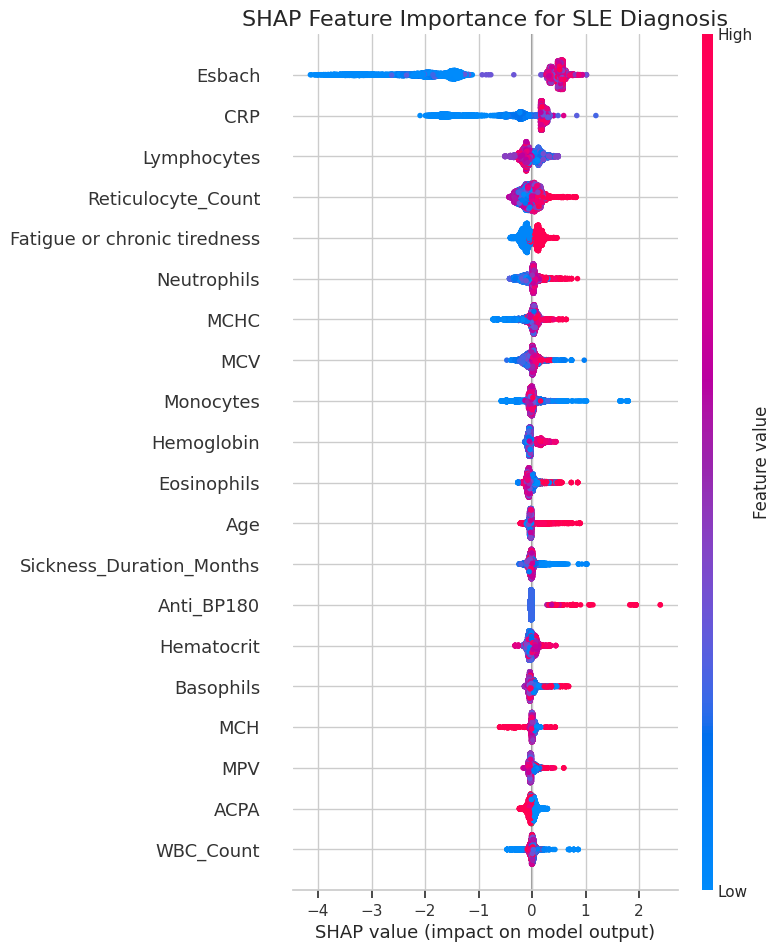

In [34]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Feature Importance for SLE Diagnosis", fontsize=16)
plt.show()

In [35]:
# Fairness Check (By Gender)
metrics = {'FNR': false_negative_rate, 'accuracy': accuracy_score}
mf = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=X_test['Gender']
)
print("Fairness Check (By Gender")
print(mf.by_group)

Fairness Check (By Gender
             FNR  accuracy
Gender                    
0       0.452000  0.948094
1       0.500994  0.946234


Partial Dependence Plots (PDP)

Generating Partial Dependence Plots...


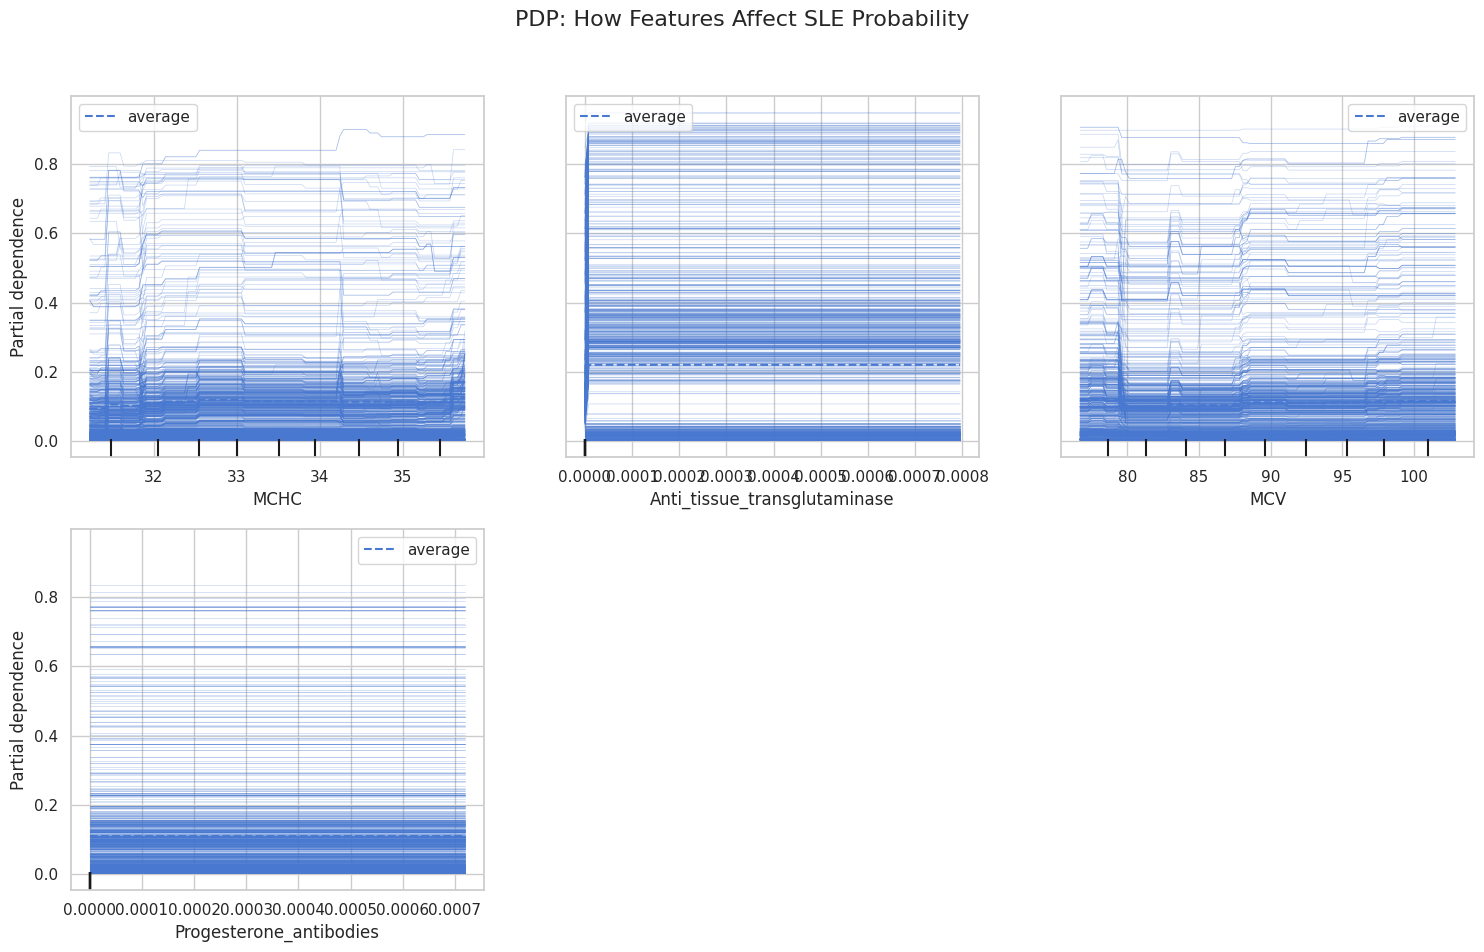

In [38]:
from sklearn.inspection import PartialDependenceDisplay

top_features = X_train.columns[:4].tolist()

print("Generating Partial Dependence Plots")
fig, ax = plt.subplots(figsize=(15, 10))
display = PartialDependenceDisplay.from_estimator(
    xgb_model,
    X_train,
    features=top_features,
    kind="both",
    ax=ax
)
plt.suptitle("PDP: How Features Affect SLE Probability", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 2. Second Model (WaOE)

In [39]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [40]:
# Handling Missing Values & Scaling
imputer = SimpleImputer(strategy='mean')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

In [41]:
# Balancing Data using SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_imp, y_train)

In [42]:
# Standardizing
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test_imp)

In [43]:
# Base Models for Ensemble
base_ensemble = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(random_state=42)),
        ('svc', SVC(probability=True, random_state=42)),
        ('lr', LogisticRegression(max_iter=3000, random_state=42))
    ],
    voting='soft'
)

In [44]:
# Training & Predicting
base_ensemble.fit(X_train_scaled, y_train_res)
y_ens_pred = base_ensemble.predict(X_test_scaled)

print(f"Ensemble Accuracy: {accuracy_score(y_test, y_ens_pred)*100:.2f}%")
print("\nClassification Report (Ensemble):")
print(classification_report(y_test, y_ens_pred, target_names=['Non-SLE', 'SLE']))

Ensemble Accuracy: 98.14%

Classification Report (Ensemble):
              precision    recall  f1-score   support

     Non-SLE       0.99      0.99      0.99      8038
         SLE       0.89      0.95      0.92      1003

    accuracy                           0.98      9041
   macro avg       0.94      0.97      0.95      9041
weighted avg       0.98      0.98      0.98      9041

